# Electronic Parts Classifier: Project Analysis Notebook

This notebook is designed for external reviewers, analysts, and technical stakeholders.
It presents a structured performance review of the final computer vision pipeline, with clear metrics, visual diagnostics, and evidence-based interpretation.

## Project Context

- Problem type: multi-class image classification of electronic components
- Final backbone: EfficientNet-B0
- Baseline for comparison: ResNet18
- Main evaluation artifacts: `metrics.json`, `classification_report.json`, `problematic_classes.json`, and confusion matrix plots

## Workflow Overview

This report follows a simple analytical flow:

1. Load generated artifacts from the training/evaluation pipeline
2. Summarize core KPI values
3. Analyze training behavior over epochs
4. Compare baseline and final model performance
5. Review class-level strengths and weaknesses
6. Inspect confusion matrix behavior
7. Conclude with key business/technical takeaways

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd()
if not (ROOT / "reports").exists() and (ROOT.parent / "reports").exists():
    ROOT = ROOT.parent

REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"

paths = {
    "metrics": REPORTS / "metrics.json",
    "class_report": REPORTS / "classification_report.json",
    "problematic": REPORTS / "problematic_classes.json",
    "cm": FIGURES / "confusion_matrix.png",
}

for key, p in paths.items():
    print(f"{key:12s}: {p} -> {'OK' if p.exists() else 'MISSING'}")

metrics     : c:\Users\Stjepan\NeuralNet Electronic Parts Classifier\reports\metrics.json -> OK
class_report: c:\Users\Stjepan\NeuralNet Electronic Parts Classifier\reports\classification_report.json -> OK
problematic : c:\Users\Stjepan\NeuralNet Electronic Parts Classifier\reports\problematic_classes.json -> OK
cm          : c:\Users\Stjepan\NeuralNet Electronic Parts Classifier\reports\figures\confusion_matrix.png -> OK


### Artifact Discovery and Validation

This cell validates that all expected report files are available before analysis starts.
If any file is missing, subsequent sections may be incomplete or misleading.

In [2]:
with open(paths["metrics"], "r", encoding="utf-8") as f:
    metrics = json.load(f)

with open(paths["class_report"], "r", encoding="utf-8") as f:
    class_report = json.load(f)

problematic_df = None
if paths["problematic"].exists():
    with open(paths["problematic"], "r", encoding="utf-8") as f:
        problematic_df = pd.DataFrame(json.load(f))

summary = pd.DataFrame([
    {
        "model_name": metrics.get("model_name"),
        "best_epoch": metrics.get("best_epoch"),
        "best_val_macro_f1": metrics.get("best_val_macro_f1"),
        "test_accuracy": metrics.get("test_acc"),
        "test_macro_f1": metrics.get("test_macro_f1"),
        "test_loss": metrics.get("test_loss"),
    }
])

display(Markdown("## 2. KPI Summary"))
display(summary.style.format({
    "best_val_macro_f1": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_loss": "{:.4f}",
}))

## 2. KPI Summary

,model_name,best_epoch,best_val_macro_f1,test_accuracy,test_macro_f1,test_loss
0,efficientnet_b0,8,0.4243,0.4323,0.4391,2.0425


### KPI Snapshot

This section provides the primary model-level KPIs used in project communication: test accuracy, test macro-F1, validation macro-F1 at best epoch, and test loss.
These values are the fastest way to evaluate whether the final model is an improvement over baseline.

## 3. Training Dynamics (Loss and Macro-F1)

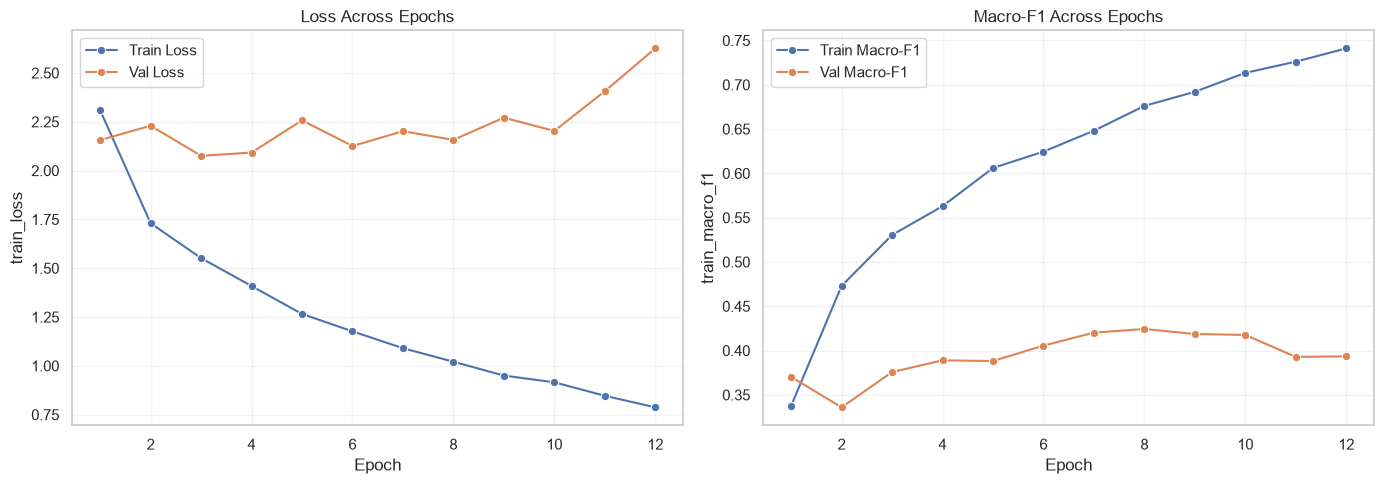

In [3]:
history_df = pd.DataFrame(metrics.get("history", []))

display(Markdown("## 3. Training Dynamics (Loss and Macro-F1)"))
if history_df.empty:
    print("No training history found in metrics.json")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=history_df, x="epoch", y="train_loss", marker="o", ax=axes[0], label="Train Loss")
    sns.lineplot(data=history_df, x="epoch", y="val_loss", marker="o", ax=axes[0], label="Val Loss")
    axes[0].set_title("Loss Across Epochs")

    sns.lineplot(data=history_df, x="epoch", y="train_macro_f1", marker="o", ax=axes[1], label="Train Macro-F1")
    sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", marker="o", ax=axes[1], label="Val Macro-F1")
    axes[1].set_title("Macro-F1 Across Epochs")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

### Learning Curve Interpretation

Loss and macro-F1 trajectories are shown side by side to evaluate optimization quality and generalization behavior.
A stable gap between train and validation curves is expected; a widening gap can indicate increasing overfitting risk.

## 4. Model Comparison (Baseline vs Final)

,Model,Test Accuracy,Test Macro-F1
0,ResNet18,0.3946,0.4053
1,EfficientNet-B0,0.4323,0.4391


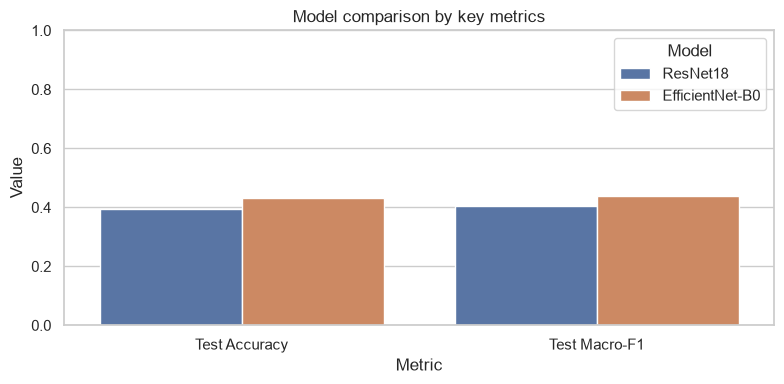

In [4]:
display(Markdown("## 4. Model Comparison (Baseline vs Final)"))
comparison = pd.DataFrame([
    {"Model": "ResNet18", "Test Accuracy": 0.3946, "Test Macro-F1": 0.4053},
    {"Model": "EfficientNet-B0", "Test Accuracy": metrics.get("test_acc", None), "Test Macro-F1": metrics.get("test_macro_f1", None)},
])
display(comparison.style.format({"Test Accuracy": "{:.4f}", "Test Macro-F1": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(8, 4))
comparison_melt = comparison.melt(id_vars=["Model"], var_name="Metric", value_name="Value")
sns.barplot(data=comparison_melt, x="Metric", y="Value", hue="Model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model comparison by key metrics")
plt.tight_layout()
plt.show()

### Baseline vs Final Backbone

This comparison isolates the practical impact of moving from ResNet18 to EfficientNet-B0.
The bar chart helps communicate the uplift in both overall accuracy and class-balanced performance (macro-F1).

## 5. Per-Class Analysis and Problematic Categories

### Bottom 10 Classes by F1

,class,precision,recall,f1_score,support
0,local-oscillator,0.000,0.000,0.000,12.000000
1,light-circuit,0.077,0.167,0.105,6.000000
2,Integrated-micro-circuit,0.152,0.106,0.125,47.000000
3,junction-transistor,0.200,0.100,0.133,50.000000
4,relay,0.154,0.133,0.143,45.000000
5,step-up-transformer,0.273,0.188,0.222,16.000000
6,microchip,0.244,0.213,0.227,47.000000
7,semi-conductor,0.333,0.209,0.257,43.000000
8,Bypass-capacitor,0.348,0.258,0.296,31.000000
9,potential-divider,0.333,0.292,0.311,24.000000


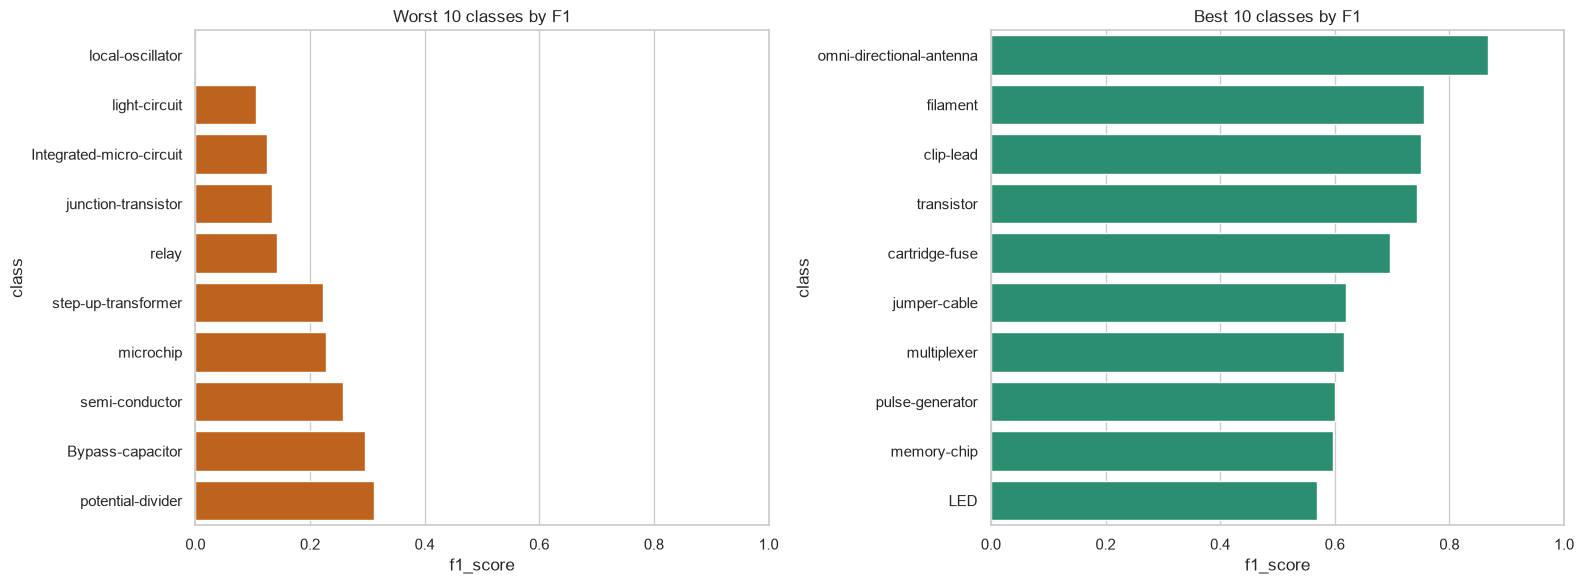

In [5]:
display(Markdown("## 5. Per-Class Analysis and Problematic Categories"))

if problematic_df is None or problematic_df.empty:
    print("problematic_classes.json is not available.")
else:
    problematic_df = problematic_df.sort_values("f1_score", ascending=True).reset_index(drop=True)
    worst_10 = problematic_df.head(10)
    best_10 = problematic_df.tail(10).sort_values("f1_score", ascending=False)

    display(Markdown("### Bottom 10 Classes by F1"))
    display(worst_10[["class", "precision", "recall", "f1_score", "support"]].style.format({
        "precision": "{:.3f}", "recall": "{:.3f}", "f1_score": "{:.3f}"
    }))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=worst_10, y="class", x="f1_score", ax=axes[0], color="#d95f02")
    axes[0].set_title("Worst 10 classes by F1")
    axes[0].set_xlim(0, 1)

    sns.barplot(data=best_10, y="class", x="f1_score", ax=axes[1], color="#1b9e77")
    axes[1].set_title("Best 10 classes by F1")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

### Confusion Structure Review

After reviewing bottom and top classes, the confusion matrix provides a full cross-class error map.
This helps identify repeated confusion pairs and broader structural error patterns.

## 6. Confusion Matrix

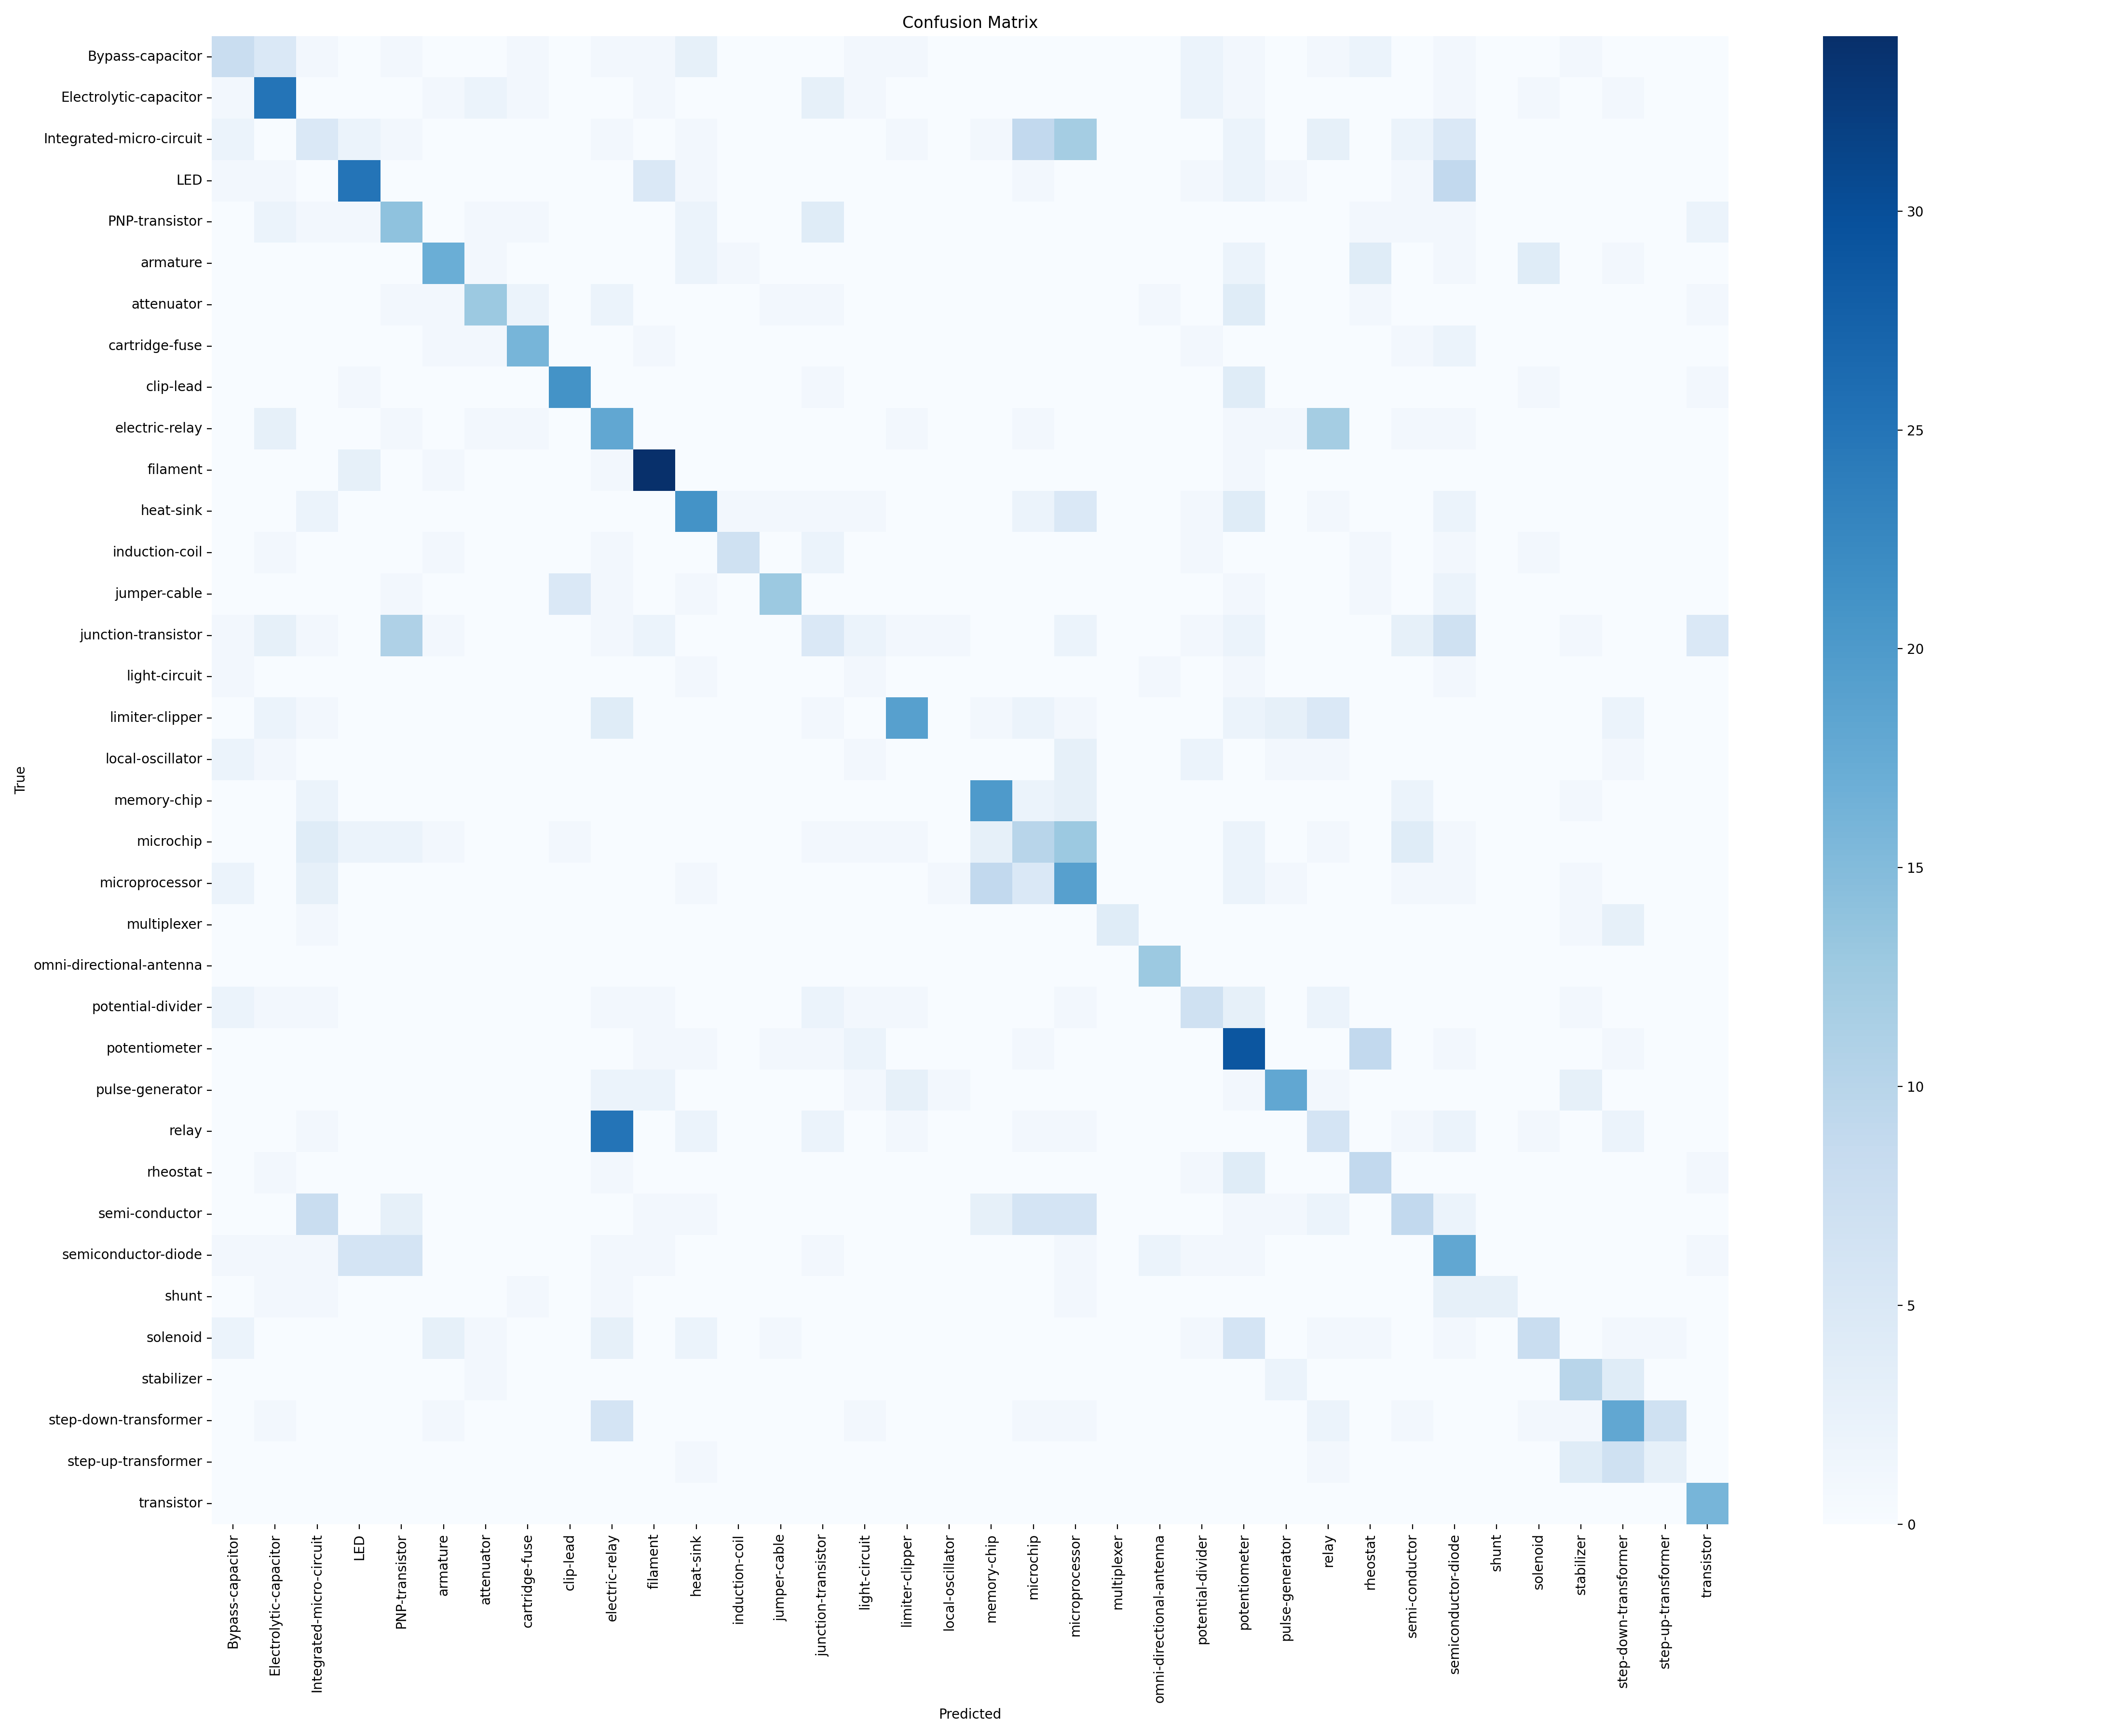

In [6]:
display(Markdown("## 6. Confusion Matrix"))
if paths["cm"].exists():
    display(Image(filename=str(paths["cm"])))
else:
    print("Confusion matrix image was not found.")

## Conclusions

### Strengths
- EfficientNet-B0 improved both accuracy and macro-F1 compared to the ResNet18 baseline.
- Training shows stable progress across epochs until the best validation window.

### Risk Areas
- Visually similar classes still produce meaningful overlap.
- Lower-support classes remain sensitive and typically show lower recall.